# 05 — Ensemble ablation, statistical comparisons and prediction intervals

- **2017 development:** rank base models, select accuracy/correlation subsets, fit one stacking model per delivery hour, and calibrate the fixed heterogeneous equal-weight ensemble's residual distribution.
- **2018 final evaluation:** evaluate the frozen configurations on one common sample; compute paired tests, confidence intervals for performance differences and prediction-interval coverage. 
- The heterogeneous composition, stacking penalties, reference and comparator list are carried over from the source and fixed in advance of this notebook's evaluation. No claim of independent preregistration is made.

### Inputs

Read `outputs/combined_base_models/base_predictions_2017.csv` and `base_predictions_2018.csv` (the full aligned outputs of Notebook 4, before complete-case filtering). If a combined file is absent, join the separate `outputs/base_models/` and `outputs/statistical_models/` files after verifying their timestamp and target agreement. Notebook 2's `data/features/` exports provide authoritative timestamps, targets, timezone and the training-only MASE denominator.

### Outputs

All results are saved under `outputs/ensemble_ablation/`: coverage audits; 2017 rankings, correlations and composition; 2018 ablation metrics and hourly predictions; stacking coefficients; daily/horizon DM–HAC tests with Holm adjustments; paired block-bootstrap confidence intervals; hourly and daily-average prediction intervals, their calibration values and probabilistic metrics; figures and an input/run manifest.

**Corrections to the source:** timezone-aware joins replace text slicing; MASE is computed from training targets rather than reverse-engineered from rounded metrics; prediction intervals are calibrated on 2017, never 2018; daily-average intervals are calibrated on daily-average errors, not averaged hourly limits; undefined plotting variables and inconsistent paths/labels are removed.


In [4]:
from pathlib import Path
import itertools
import json
import hashlib
import platform
import warnings
import scipy
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
try:
    from IPython.display import display
except ImportError:
    display = print
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / 'outputs' / 'combined_base_models'
ML_DIR = PROJECT_ROOT / 'outputs' / 'base_models'
STAT_DIR = PROJECT_ROOT / 'outputs' / 'statistical_models'
FEATURE_DIR = PROJECT_ROOT / 'data' / 'features'
OUT_DIR = PROJECT_ROOT / 'outputs' / 'ensemble_ablation'
OUT_DIR.mkdir(parents=True, exist_ok=True)
INPUT_PATHS = []

RIDGE_META_ALPHA = 1.0
ENET_META_ALPHA = 0.01
ENET_META_L1_RATIO = 0.5
HAC_LAG = 7
BOOTSTRAP_BLOCK_DAYS = 7
N_BOOTSTRAP = 5000

ALL_MODELS = [
    'LinearRegression','Ridge','ElasticNet','GradientBoosting',
    'RandomForest','XGBoost','LightGBM','Bagging','GRU','LSTM',
    'ETS_day','Naive_day'
]

INTERVAL_ALPHA = 0.05
REFERENCE = 'Diversity-guided heterogeneous | Equal weight'

COMPARATORS = {
 'Single ElasticNet': 'Single | ElasticNet',
 'Single Ridge': 'Single | Ridge',
 'Seasonal naive': 'Single | Naive_day',
 'Accuracy top-five ElasticNet stack': 'Accuracy-only top five | ElasticNet stacking',
 'All-model ElasticNet stack': 'All 12 models | ElasticNet stacking',
 'Diversity Ridge stack': 'Diversity-guided heterogeneous | Ridge stacking',
 'Diversity ElasticNet stack': 'Diversity-guided heterogeneous | ElasticNet stacking',
 'Non-statistical ML-DL ElasticNet stack': 'Non-statistical ML-DL | ElasticNet stacking',
}


## 1. Load and verify the upstream prediction contract

Reject duplicate instants, missing/extra target timestamps, incorrect years, inconsistent targets and infinite forecasts. Preserve expected Naive_day missingness for the common-sample audit. The same ordered list of 12 base models is required for both years.


In [6]:
def record_input(path):
    if not path.is_file():
        raise FileNotFoundError(f'Missing {path}. Run the preceding notebooks or set PROJECT_ROOT.')
    INPUT_PATHS.append(path)
    return path

manifest = json.loads(record_input(FEATURE_DIR / 'feature_manifest.json').read_text())
TIMEZONE = manifest['timezone']

if manifest['forecast_horizon'] != 24:
    raise ValueError('This notebook requires 24-hour targets.')

metadata = pd.read_csv(record_input(FEATURE_DIR / 'sample_metadata.csv'))
target_rows = pd.read_csv(record_input(FEATURE_DIR / 'target_timestamps.csv')).sort_values(['sample_id', 'horizon'])
with np.load(record_input(FEATURE_DIR / 'day_ahead_features.npz'), allow_pickle=False) as archive:
    targets = archive['y'].copy()
if targets.shape != (len(metadata), 24) or not np.isfinite(targets).all():
    raise ValueError('Invalid Notebook 2 targets.')
if not np.array_equal(metadata.sample_id, np.arange(len(metadata))):
    raise ValueError('Invalid metadata row order.')
if not np.array_equal(target_rows.sample_id, np.repeat(np.arange(len(metadata)), 24)):
    raise ValueError('Invalid target sample IDs.')
if not np.array_equal(target_rows.horizon, np.tile(np.arange(1, 25), len(metadata))):
    raise ValueError('Invalid horizon order.')
feature_days = pd.DatetimeIndex(pd.to_datetime(metadata.delivery_day)).tz_localize(TIMEZONE)
if not feature_days.is_unique or not feature_days.is_monotonic_increasing or not np.array_equal(feature_days.year, metadata.delivery_year):
    raise ValueError('Invalid delivery-day metadata.')
if set(metadata.delivery_year) != {2015, 2016, 2017, 2018}:
    raise ValueError('Expected delivery years 2015–2018.')
feature_index = pd.DatetimeIndex(pd.to_datetime(target_rows.target_timestamp, utc=True)).tz_convert(TIMEZONE)
if not feature_index.is_unique or not feature_index.is_monotonic_increasing:
    raise ValueError('Invalid target timestamp ordering.')
if not np.array_equal(feature_index.normalize().asi8, np.repeat(feature_days.asi8, 24)):
    raise ValueError('Target timestamp days disagree with metadata.')
if not np.array_equal(feature_index.hour, np.tile(np.arange(24), len(metadata))):
    raise ValueError('Expected local hours 00–23 per day.')
feature_targets = pd.Series(targets.ravel().astype(float), index=feature_index)


def read_forecast(path):
    frame = pd.read_csv(record_input(path))
    if 'time' not in frame or 'y_true' not in frame:
        raise ValueError(f'{path}: time and y_true are required.')
    frame.index = pd.DatetimeIndex(pd.to_datetime(frame.pop('time'), utc=True)).tz_convert(TIMEZONE)
    if not frame.index.is_unique:
        raise ValueError(f'{path}: duplicate UTC instants.')
    return frame.sort_index()


def load_predictions(year):
    path = DATA_DIR / f'base_predictions_{year}.csv'
    if path.exists():
        frame = read_forecast(path)
    else:
        ml = read_forecast(ML_DIR / f'base_predictions_{year}.csv')
        statistical = read_forecast(STAT_DIR / f'base_predictions_{year}.csv')
        if not ml.index.equals(statistical.index) or not np.allclose(ml.y_true, statistical.y_true, rtol=1e-5, atol=1e-4):
            raise ValueError('ML/DL and statistical predictions are not aligned.')
        frame = ml.drop(columns=['ETS_day', 'Naive_day'], errors='ignore').join(statistical[['ETS_day', 'Naive_day']])
    required = ['y_true', *ALL_MODELS]
    missing = set(required).difference(frame.columns)
    if missing:
        raise KeyError(f'Missing model columns: {sorted(missing)}')
    expected = feature_targets.loc[feature_targets.index.year == year]
    if not frame.index.equals(expected.index):
        raise ValueError(f'{year}: timestamps must match all Notebook 2 eligible targets, before filtering.')
    if not np.allclose(frame.y_true, expected, rtol=1e-5, atol=1e-4):
        raise ValueError(f'{year}: targets differ from Notebook 2.')
    values = frame[required].to_numpy(dtype=float)
    if np.isinf(values).any():
        raise ValueError(f'{year}: infinite target/prediction values.')
    result = frame[required].copy()
    result.insert(0, 'time', frame.index)
    result['local_day'] = frame.index.strftime('%Y-%m-%d')
    result['hour'] = frame.index.hour
    return result.reset_index(drop=True)

p2017 = load_predictions(2017)
p2018 = load_predictions(2018)
print('Eligible input hours:', len(p2017), len(p2018))


Eligible input hours: 8712 8712


## 2. One global common sample per year

Every model and ensemble uses exactly the same complete local delivery days. Export excluded-day counts and the affected model names so the loss of days after DST is visible. Missing forecasts are not imputed. Common samples may have calendar gaps; inference functions below preserve actual calendar lags and never build bootstrap blocks across a gap.


In [8]:
def global_complete_sample(frame, year):
    complete = np.isfinite(frame[['y_true', *ALL_MODELS]].to_numpy(dtype=float)).all(axis=1)
    audit_rows = []
    keep_days = []
    for day, group in frame.groupby('local_day', sort=True):
        complete_day = (len(group) == 24 and np.array_equal(group.hour.to_numpy(), np.arange(24))
                        and complete[group.index].all())
        bad_models = [name for name in ALL_MODELS if not np.isfinite(group[name]).all()]
        audit_rows.append({'year': year, 'delivery_day': day, 'retained': bool(complete_day),
                           'input_hours': len(group), 'missing_models': ', '.join(bad_models)})
        if complete_day:
            keep_days.append(day)
    clean = frame.loc[frame.local_day.isin(keep_days)].sort_values(['local_day', 'hour']).reset_index(drop=True)
    if clean.empty:
        raise ValueError(f'{year}: no common complete days.')
    pd.DataFrame(audit_rows).to_csv(OUT_DIR / f'common_sample_audit_{year}.csv', index=False)
    print(year, 'common days:', len(keep_days), 'hours:', len(clean))
    return clean

g2017 = global_complete_sample(p2017, 2017)
g2018 = global_complete_sample(p2018, 2018)


2017 common days: 361 hours: 8664
2018 common days: 361 hours: 8664


## 3. Development-year rankings, correlations and compositions

Accuracy selection uses the five lowest 2017 RMSE values. Correlation selection exhaustively checks all five-model combinations using mean absolute **prediction** correlation, preserving the source criterion. Error correlation is exported separately as a diagnostic. Ties follow the fixed model-list order. Low prediction correlation does not by itself establish useful error diversity.

The heterogeneous five-model composition is carried over unchanged from the source. All subsets and stacking penalties are frozen before final evaluation.


In [10]:
validation_rmse = {
    m: mean_squared_error(g2017['y_true'],g2017[m])**0.5 for m in ALL_MODELS
}
accuracy_top5 = sorted(ALL_MODELS,key=validation_rmse.get)[:5]

corr2017 = g2017[ALL_MODELS].corr()
if not np.isfinite(corr2017.to_numpy()).all():
    raise ValueError('Correlation selection requires nonconstant finite predictions.')
corr2017.to_csv(OUT_DIR / 'prediction_correlation_2017.csv')
def mean_abs_corr(combo):
    a=corr2017.loc[list(combo),list(combo)].to_numpy()
    return np.abs(a[np.triu_indices(len(combo),1)]).mean()

least_corr5 = list(min(itertools.combinations(ALL_MODELS,5),key=mean_abs_corr))
rank2017=(pd.Series(validation_rmse,name='validation_RMSE').rename_axis('model')
          .sort_values().reset_index())
rank2017.to_csv(OUT_DIR/'validation_ranking_2017_global_sample.csv',index=False)
display(rank2017)
print('Accuracy top five:',accuracy_top5)
print('Least-correlated five:',least_corr5,'score',mean_abs_corr(least_corr5))


,model,validation_RMSE
0,ElasticNet,9.078711
1,Ridge,9.115999
2,LightGBM,9.783202
3,GradientBoosting,10.018824
4,XGBoost,10.433707
5,GRU,10.590584
6,LinearRegression,10.641723
7,LSTM,10.768431
8,Naive_day,10.860758
9,RandomForest,11.286727


Accuracy top five: ['ElasticNet', 'Ridge', 'LightGBM', 'GradientBoosting', 'XGBoost']
Least-correlated five: ['XGBoost', 'Bagging', 'LSTM', 'ETS_day', 'Naive_day'] score 0.6351923548737007


In [12]:
CONFIGURATIONS = {
 'Diversity-guided heterogeneous':['LinearRegression','GradientBoosting','GRU','ETS_day','Naive_day'],
 'Accuracy-only top five':accuracy_top5,
 'All 12 models':ALL_MODELS,
 'Non-statistical ML-DL':[m for m in ALL_MODELS if m not in {'ETS_day','Naive_day'}],
 'Homogeneous tree-based':['GradientBoosting','RandomForest','XGBoost','LightGBM','Bagging'],
 'Five least-correlated (2017)':least_corr5,
}
for k,v in CONFIGURATIONS.items(): print(k,':',v)

pd.DataFrame([{'configuration': name, 'models': json.dumps(models), 'n_models': len(models)}
              for name, models in CONFIGURATIONS.items()]).to_csv(OUT_DIR / 'ensemble_compositions.csv', index=False)


Diversity-guided heterogeneous : ['LinearRegression', 'GradientBoosting', 'GRU', 'ETS_day', 'Naive_day']
Accuracy-only top five : ['ElasticNet', 'Ridge', 'LightGBM', 'GradientBoosting', 'XGBoost']
All 12 models : ['LinearRegression', 'Ridge', 'ElasticNet', 'GradientBoosting', 'RandomForest', 'XGBoost', 'LightGBM', 'Bagging', 'GRU', 'LSTM', 'ETS_day', 'Naive_day']
Non-statistical ML-DL : ['LinearRegression', 'Ridge', 'ElasticNet', 'GradientBoosting', 'RandomForest', 'XGBoost', 'LightGBM', 'Bagging', 'GRU', 'LSTM']
Homogeneous tree-based : ['GradientBoosting', 'RandomForest', 'XGBoost', 'LightGBM', 'Bagging']
Five least-correlated (2017) : ['XGBoost', 'Bagging', 'LSTM', 'ETS_day', 'Naive_day']


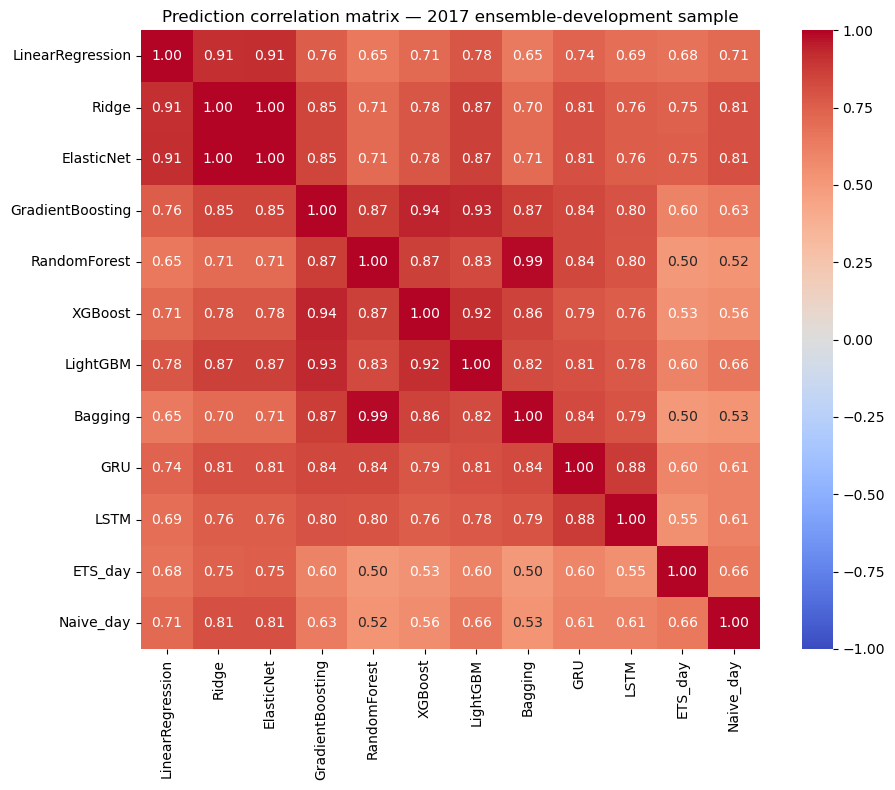

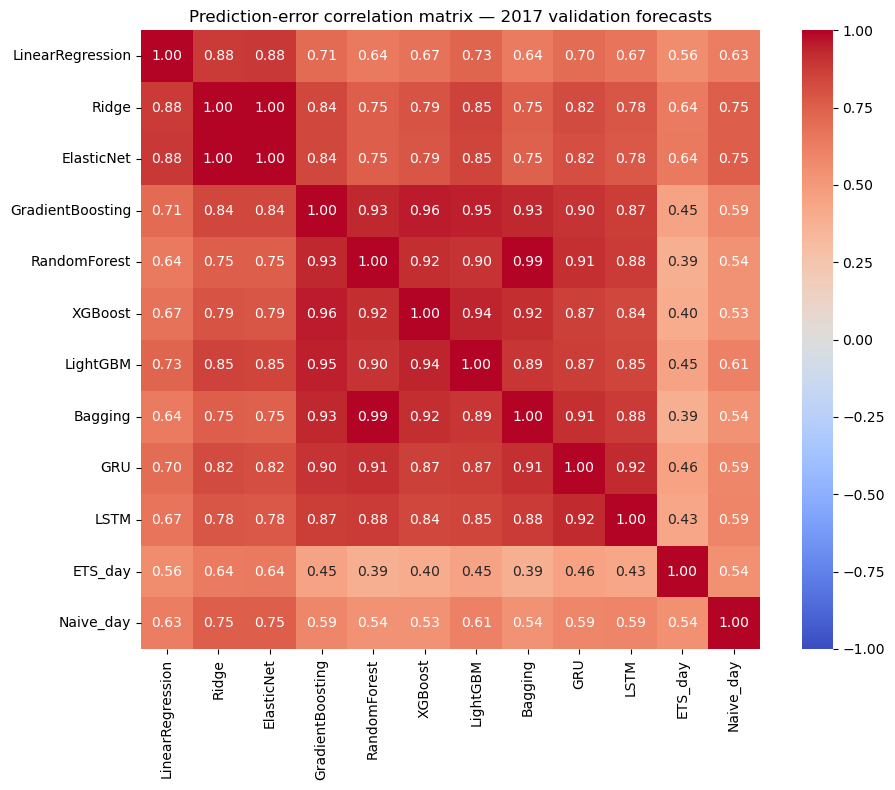

In [14]:
plt.figure(figsize=(10,8))
sns.heatmap(corr2017,annot=True,fmt='.2f',cmap='coolwarm',vmin=-1,vmax=1,square=True)
plt.title('Prediction correlation matrix — 2017 ensemble-development sample')
plt.tight_layout()
plt.savefig(OUT_DIR/'prediction_correlation_2017.png',dpi=300,bbox_inches='tight')
plt.show()

error_corr2017=g2017[ALL_MODELS].sub(g2017['y_true'],axis=0).corr()
error_corr2017.to_csv(OUT_DIR/'error_correlation_2017.csv')

plt.figure(figsize=(10,8))
sns.heatmap(error_corr2017,annot=True,fmt='.2f',cmap='coolwarm',vmin=-1,vmax=1,square=True)
plt.title('Prediction-error correlation matrix — 2017 validation forecasts')
plt.tight_layout()
plt.savefig(OUT_DIR/'prediction_error_correlation_2017.png',dpi=300,bbox_inches='tight')
plt.show()


## 4. Per-hour stacking and metrics

Fit a separate standardized Ridge or ElasticNet regression for each of 24 delivery hours using the 2017 out-of-sample base forecasts and targets. Apply it unchanged to the 2018 base forecasts. The source's fixed penalties are retained; no tuning on 2018 occurs. Coefficients are unconstrained, need not be positive or sum to one, and include an intercept. Export coefficients on the original price scale.

MASE uses Notebook 2 targets from 2015–2017 paired exactly 24 elapsed hours apart, matching Notebooks 3 and 4. Missing lag pairs are omitted. MAPE is diagnostic because prices can approach zero. The 2018 table is a final comparison, not a model-selection step.


In [16]:
def daily_arrays(clean,models):
    n_days=clean.local_day.nunique()
    y=clean.y_true.to_numpy(float).reshape(n_days,24)
    X=np.stack([clean[m].to_numpy(float).reshape(n_days,24) for m in models],axis=2)
    days=pd.Index(clean.local_day.drop_duplicates())
    return days,y,X

history = feature_targets.loc[feature_targets.index.year.isin([2015, 2016, 2017])]
previous = history.reindex(history.index - pd.Timedelta(hours=24)).to_numpy()
valid = np.isfinite(previous)
MASE_SCALE_2018 = float(np.mean(np.abs(history.to_numpy()[valid] - previous[valid])))
if not np.isfinite(MASE_SCALE_2018) or MASE_SCALE_2018 <= 0:
    raise ValueError('Undefined training-only MASE scale.')

def evaluate(y,p):
    yt,yp=y.ravel(),p.ravel(); mae=mean_absolute_error(yt,yp)
    return {'MAE':mae,'RMSE':mean_squared_error(yt,yp)**0.5,
            'MAPE':np.mean(np.abs((yt-yp)/np.clip(np.abs(yt),1e-6,None)))*100,
            'R2':r2_score(yt,yp),'MASE':mae/MASE_SCALE_2018,'n_hours':len(yt)}

def meta_model(kind):
    reg=(Ridge(alpha=RIDGE_META_ALPHA) if kind=='Ridge' else
         ElasticNet(alpha=ENET_META_ALPHA,l1_ratio=ENET_META_L1_RATIO,
                    max_iter=10000,random_state=SEED))
    return Pipeline([('scaler',StandardScaler()),('regressor',reg)])

def stack_predict(x17,y17,x18,kind):
    pred=np.empty((x18.shape[0],24)); fitted=[]
    for h in range(24):
        m=meta_model(kind); m.fit(x17[:,h,:],y17[:,h]); pred[:,h]=m.predict(x18[:,h,:]); fitted.append(m)
    return fitted,pred


In [18]:
metric_rows=[]; predictions={}; coefficient_rows=[]
days17,y17_all,_=daily_arrays(g2017,ALL_MODELS)
days18,y18_all,_=daily_arrays(g2018,ALL_MODELS)

for config,models in CONFIGURATIONS.items():
    _,y17,x17=daily_arrays(g2017,models); _,y18,x18=daily_arrays(g2018,models)
    equal=x18.mean(axis=2); key=f'{config} | Equal weight'; predictions[key]=equal
    metric_rows.append({'configuration':config,'method':'Equal weight','models':', '.join(models),**evaluate(y18,equal)})
    for kind in ['Ridge','ElasticNet']:
        fitted,pred=stack_predict(x17,y17,x18,kind); key=f'{config} | {kind} stacking'; predictions[key]=pred
        metric_rows.append({'configuration':config,'method':f'{kind} stacking','models':', '.join(models),**evaluate(y18,pred)})
        for h,pipe in enumerate(fitted,1):
            sc=pipe.named_steps['scaler']; reg=pipe.named_steps['regressor']
            raw=np.asarray(reg.coef_)/sc.scale_
            intercept=float(reg.intercept_-np.sum(np.asarray(reg.coef_)*sc.mean_/sc.scale_))
            for model_name,coef in zip(models,raw):
                coefficient_rows.append({'configuration':config,'meta_model':kind,'horizon':h,
                                         'base_model':model_name,'raw_coefficient':coef,'raw_intercept':intercept})

for model in ALL_MODELS:
    pred=g2018[model].to_numpy(float).reshape(-1,24); predictions[f'Single | {model}']=pred
    metric_rows.append({'configuration':'Single base model','method':model,'models':model,**evaluate(y18_all,pred)})

metrics_df=pd.DataFrame(metric_rows).sort_values(['MAE','RMSE']).reset_index(drop=True)
assert metrics_df.n_hours.nunique()==1, 'Configurations were evaluated on different samples.'
metrics_df.to_csv(OUT_DIR/'ablation_metrics_2018_global_sample.csv',index=False)
pd.DataFrame(coefficient_rows).to_csv(OUT_DIR/'stacking_coefficients_raw_scale.csv',index=False)
display(metrics_df[['configuration','method','MAE','RMSE','MAPE','R2','MASE','n_hours']])


,configuration,method,MAE,RMSE,MAPE,R2,MASE,n_hours
0,Diversity-guided heterogeneous,Equal weight,6.147281,8.666624,19.554390,0.542400,0.777773,8664
1,Accuracy-only top five,ElasticNet stacking,6.325402,8.881973,22.758070,0.519376,0.800309,8664
2,Accuracy-only top five,Ridge stacking,6.345971,8.896079,22.768669,0.517848,0.802912,8664
3,Diversity-guided heterogeneous,ElasticNet stacking,6.358008,8.962798,22.115730,0.510589,0.804435,8664
4,Diversity-guided heterogeneous,Ridge stacking,6.363199,8.968816,22.124618,0.509932,0.805091,8664
5,Five least-correlated (2017),ElasticNet stacking,6.441618,9.046702,22.193979,0.501383,0.815013,8664
6,Five least-correlated (2017),Ridge stacking,6.444732,9.049629,22.200870,0.501060,0.815407,8664
7,Single base model,ElasticNet,6.511160,8.825554,20.998290,0.525463,0.823812,8664
8,Single base model,Ridge,6.529498,8.855124,21.216075,0.522278,0.826132,8664
9,All 12 models,ElasticNet stacking,6.626027,9.145991,23.296652,0.490378,0.838345,8664


In [20]:
# Export every prediction on the original common hourly timestamps.
pred_out=g2018[['time','local_day','hour','y_true']].copy()
for key,mat in predictions.items(): pred_out[key]=mat.ravel()
pred_out.to_csv(OUT_DIR/'all_predictions_2018_global_sample.csv',index=False)


## 5. Paired daily DM–HAC comparisons

For comparator C and fixed reference R, define daily loss difference `L(C) − L(R)`; positive values favor the reference. Absolute loss averages the 24 hourly absolute errors; squared loss averages their squares.

Use Bartlett-weighted HAC variance with lags 1–7 **calendar days**, pairing only dates actually present. This is a paired mean-loss test with a Student-t reference approximation (n−1 degrees of freedom), retaining the source's convention; it is not an exact finite-sample test. Holm correction is applied across the fixed comparator list separately for absolute and squared loss. Undefined zero-variance comparisons receive missing p-values and cannot be called significant. Failure to reject is not proof of equivalence.


In [22]:
def daily_loss(y,p,loss):
    e=y-p
    return np.mean(np.abs(e),axis=1) if loss=='absolute' else np.mean(e**2,axis=1)

def dm_hac(d, max_lag=7):
    d = np.asarray(d, dtype=float)
    n = len(d)
    if n < 3 or not np.isfinite(d).all() or n != len(days18):
        raise ValueError('DM requires aligned finite daily losses.')
    dates = pd.DatetimeIndex(pd.to_datetime(days18))
    centered = pd.Series(d - d.mean(), index=dates)
    long_var = float(np.dot(centered, centered) / n)
    for lag in range(1, max_lag + 1):
        previous = centered.reindex(dates - pd.Timedelta(days=lag)).to_numpy()
        valid = np.isfinite(previous)
        gamma = np.dot(centered.to_numpy()[valid], previous[valid]) / n
        long_var += 2 * (1 - lag / (max_lag + 1)) * gamma
    if np.all(d == 0):
        return 0.0, 0.0, 1.0
    if long_var <= np.finfo(float).eps * max(1.0, np.mean(d ** 2)):
        return float(d.mean()), np.nan, np.nan
    statistic = float(d.mean() / np.sqrt(long_var / n))
    p = float(2 * stats.t.sf(abs(statistic), df=n - 1))
    return float(d.mean()), statistic, p

def holm_adjust(pvalues):
    p = np.asarray(pvalues, dtype=float)
    finite = np.isfinite(p)
    if ((p[finite] < 0) | (p[finite] > 1)).any():
        raise ValueError('P-values must lie in [0, 1].')
    # Treat undefined tests as p=1 for family size; restore NaNs in the output.
    safe = np.where(finite, p, 1.0)
    order = np.argsort(safe, kind='stable')
    adjusted = np.empty_like(p)
    running = 0.0
    for rank, idx in enumerate(order):
        running = max(running, (len(p) - rank) * safe[idx])
        adjusted[idx] = min(running, 1.0)
    adjusted[~finite] = np.nan
    return adjusted

dm_rows=[]
for loss in ['absolute','squared']:
    ref_loss=daily_loss(y18_all,predictions[REFERENCE],loss)
    family=[]
    for label,key in COMPARATORS.items():
        comp_loss=daily_loss(y18_all,predictions[key],loss)
        mean_diff,stat,p=dm_hac(comp_loss-ref_loss,HAC_LAG)
        family.append({'reference':REFERENCE,'comparator':label,'loss':loss,
                       'mean_loss_advantage':mean_diff,'dm_statistic':stat,'p_value':p})
    adjusted=holm_adjust([r['p_value'] for r in family])
    for row,padj in zip(family,adjusted): row['holm_p_value']=padj; row['significant_0_05']=padj<0.05
    dm_rows.extend(family)

dm_df=pd.DataFrame(dm_rows)
dm_df.to_csv(OUT_DIR/'daily_DM_tests_Holm.csv',index=False)
display(dm_df)


,reference,comparator,loss,mean_loss_advantage,dm_statistic,p_value,holm_p_value,significant_0_05
0,Diversity-guided heterogeneous | Equal weight,Single ElasticNet,absolute,0.363879,3.000201,2.885950e-03,0.014862,True
1,Diversity-guided heterogeneous | Equal weight,Single Ridge,absolute,0.382217,3.047612,2.477077e-03,0.014862,True
2,Diversity-guided heterogeneous | Equal weight,Seasonal naive,absolute,0.828305,4.079882,5.552179e-05,0.000444,True
3,Diversity-guided heterogeneous | Equal weight,Accuracy top-five ElasticNet stack,absolute,0.178121,1.271517,2.043656e-01,0.236145,False
4,Diversity-guided heterogeneous | Equal weight,All-model ElasticNet stack,absolute,0.478746,2.940094,3.493067e-03,0.014862,True
5,Diversity-guided heterogeneous | Equal weight,Diversity Ridge stack,absolute,0.215919,1.763200,7.871507e-02,0.236145,False
6,Diversity-guided heterogeneous | Equal weight,Diversity ElasticNet stack,absolute,0.210727,1.722689,8.580358e-02,0.236145,False
7,Diversity-guided heterogeneous | Equal weight,Non-statistical ML-DL ElasticNet stack,absolute,0.567498,3.201257,1.490035e-03,0.010430,True
8,Diversity-guided heterogeneous | Equal weight,Single ElasticNet,squared,2.780039,1.176662,2.401077e-01,0.502380,False
9,Diversity-guided heterogeneous | Equal weight,Single Ridge,squared,3.302848,1.383202,1.674601e-01,0.502380,False


## 6. Paired moving-block bootstrap confidence intervals

These are **confidence intervals for performance differences**, not price prediction intervals. Sample blocks of seven consecutive calendar days, drawing only blocks that do not cross missing-day gaps or wrap the year boundary. Apply identical indices to the reference and comparator. Blocks are sampled with replacement until the retained sample length is reached. The final sampled block is truncated if needed.

The resampling approximates short-term dependence and assumes the observed blocks are representative; endpoint observations have the usual moving-block sampling imbalance. Percentile 95% intervals are pointwise, not multiplicity-adjusted. Report the observed advantage as well as the bootstrap mean; do not use these intervals to override the Holm-adjusted test families.


In [24]:
def calendar_block_candidates(days, length):
    dates = pd.DatetimeIndex(pd.to_datetime(days))
    blocks = []
    for start in range(len(dates) - length + 1):
        block = dates[start:start + length]
        if (np.diff(block.asi8) == pd.Timedelta(days=1).value).all():
            blocks.append(np.arange(start, start + length))
    if not blocks:
        raise ValueError('No consecutive calendar blocks of the requested length.')
    return np.asarray(blocks)


def bootstrap_improvement(y, ref, comp, days, n_boot=5000, block_days=7, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y)
    blocks = calendar_block_candidates(days, block_days)
    indices = blocks[rng.integers(0, len(blocks), size=(n_boot, int(np.ceil(n / block_days))))].reshape(n_boot, -1)[:, :n]
    abs_ref, abs_comp = np.abs(y - ref).mean(axis=1), np.abs(y - comp).mean(axis=1)
    sq_ref, sq_comp = ((y - ref) ** 2).mean(axis=1), ((y - comp) ** 2).mean(axis=1)
    mae = (abs_comp[indices] - abs_ref[indices]).mean(axis=1)
    rmse = np.sqrt(sq_comp[indices].mean(axis=1)) - np.sqrt(sq_ref[indices].mean(axis=1))
    observed = {'MAE': float(abs_comp.mean() - abs_ref.mean()),
                'RMSE': float(np.sqrt(sq_comp.mean()) - np.sqrt(sq_ref.mean()))}
    return {metric: {'observed_advantage': observed[metric], 'mean_bootstrap_advantage': float(values.mean()),
                     'ci_2_5': float(np.quantile(values, .025)), 'ci_97_5': float(np.quantile(values, .975))}
            for metric, values in [('MAE', mae), ('RMSE', rmse)]}

boot_rows = []
for i, (label, key) in enumerate(COMPARATORS.items()):
    summaries = bootstrap_improvement(y18_all, predictions[REFERENCE], predictions[key], days18,
                                      N_BOOTSTRAP, BOOTSTRAP_BLOCK_DAYS, SEED + i)
    for metric, values in summaries.items():
        boot_rows.append({'reference': REFERENCE, 'comparator': label, 'metric': metric, **values,
                          'pointwise_ci_excludes_zero': values['ci_2_5'] > 0 or values['ci_97_5'] < 0,
                          'block_calendar_days': BOOTSTRAP_BLOCK_DAYS, 'replications': N_BOOTSTRAP})
boot_df = pd.DataFrame(boot_rows)
boot_df.to_csv(OUT_DIR / 'paired_block_bootstrap_CI.csv', index=False)
display(boot_df)


,reference,comparator,metric,observed_advantage,mean_bootstrap_advantage,ci_2_5,ci_97_5,pointwise_ci_excludes_zero,block_calendar_days,replications
0,Diversity-guided heterogeneous | Equal weight,Single ElasticNet,MAE,0.363879,0.355388,0.117676,0.594345,True,7,5000
1,Diversity-guided heterogeneous | Equal weight,Single ElasticNet,RMSE,0.158930,0.149094,-0.121086,0.426623,False,7,5000
2,Diversity-guided heterogeneous | Equal weight,Single Ridge,MAE,0.382217,0.374902,0.136531,0.619988,True,7,5000
3,Diversity-guided heterogeneous | Equal weight,Single Ridge,RMSE,0.188500,0.172120,-0.089187,0.447311,False,7,5000
4,Diversity-guided heterogeneous | Equal weight,Seasonal naive,MAE,0.828305,0.770728,0.364762,1.161280,True,7,5000
5,Diversity-guided heterogeneous | Equal weight,Seasonal naive,RMSE,1.744826,1.670661,1.178013,2.175980,True,7,5000
6,Diversity-guided heterogeneous | Equal weight,Accuracy top-five ElasticNet stack,MAE,0.178121,0.125647,-0.121364,0.374289,False,7,5000
7,Diversity-guided heterogeneous | Equal weight,Accuracy top-five ElasticNet stack,RMSE,0.215349,0.115214,-0.199012,0.514695,False,7,5000
8,Diversity-guided heterogeneous | Equal weight,All-model ElasticNet stack,MAE,0.478746,0.425342,0.135727,0.730896,True,7,5000
9,Diversity-guided heterogeneous | Equal weight,All-model ElasticNet stack,RMSE,0.479367,0.384371,-0.019193,0.853100,False,7,5000


## 7. Horizon-wise comparisons and descriptive profiles

Holm adjustment covers all 24 horizon tests within each comparator/loss pair; it does not control one family across every comparator and loss. These are secondary exploratory analyses. Positive significant differences favor the reference; negative significant differences favor the comparator. Horizon 1 is local 00:00–01:00 and horizon 24 is 23:00–24:00.


In [26]:
horizon_rows=[]
for label,key in COMPARATORS.items():
    for loss in ['absolute','squared']:
        family=[]
        for h in range(24):
            if loss=='absolute':
                ref=np.abs(y18_all[:,h]-predictions[REFERENCE][:,h]); comp=np.abs(y18_all[:,h]-predictions[key][:,h])
            else:
                ref=(y18_all[:,h]-predictions[REFERENCE][:,h])**2; comp=(y18_all[:,h]-predictions[key][:,h])**2
            mean_diff,stat,p=dm_hac(comp-ref,HAC_LAG)
            family.append({'comparator':label,'loss':loss,'horizon':h+1,
                           'mean_loss_advantage':mean_diff,'dm_statistic':stat,'p_value':p})
        adjusted=holm_adjust([r['p_value'] for r in family])
        for row,padj in zip(family,adjusted): row['holm_p_value']=padj; row['significant_0_05']=padj<.05
        horizon_rows.extend(family)
horizon_df=pd.DataFrame(horizon_rows)
horizon_df.to_csv(OUT_DIR/'horizon_DM_tests_Holm.csv',index=False)
horizon_df.groupby(['comparator','loss']).significant_0_05.sum().rename('significant_horizons').reset_index()


,comparator,loss,significant_horizons
0,Accuracy top-five ElasticNet stack,absolute,0
1,Accuracy top-five ElasticNet stack,squared,0
2,All-model ElasticNet stack,absolute,7
3,All-model ElasticNet stack,squared,2
4,Diversity ElasticNet stack,absolute,2
5,Diversity ElasticNet stack,squared,1
6,Diversity Ridge stack,absolute,2
7,Diversity Ridge stack,squared,1
8,Non-statistical ML-DL ElasticNet stack,absolute,8
9,Non-statistical ML-DL ElasticNet stack,squared,3


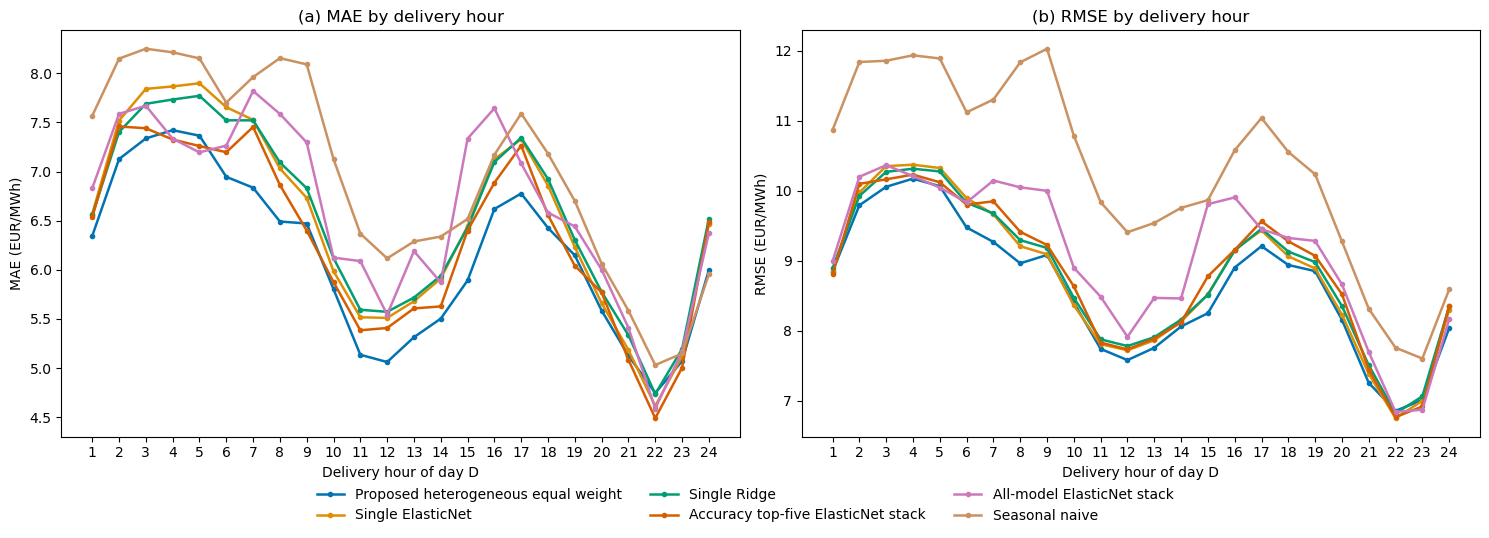

In [42]:
PLOT_METHODS = {
    'Proposed heterogeneous equal weight': REFERENCE,
    'Single ElasticNet': 'Single | ElasticNet',
    'Single Ridge': 'Single | Ridge',
    'Accuracy top-five ElasticNet stack': 'Accuracy-only top five | ElasticNet stacking',
    'All-model ElasticNet stack': 'All 12 models | ElasticNet stacking',
    'Seasonal naive': 'Single | Naive_day',
}

horizon_metric_rows = []
for label, key in PLOT_METHODS.items():
    pred = predictions[key]
    for h in range(24):
        error = y18_all[:,h] - pred[:,h]
        horizon_metric_rows.append({
            'method': label,
            'horizon': h + 1,
            'MAE': np.mean(np.abs(error)),
            'RMSE': np.sqrt(np.mean(error**2)),
        })

horizon_metrics_df = pd.DataFrame(horizon_metric_rows)
horizon_metrics_df.to_csv(OUT_DIR/'horizon_MAE_RMSE_2018.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)
palette = sns.color_palette('colorblind', n_colors=len(PLOT_METHODS))

for color, (label, group) in zip(palette, horizon_metrics_df.groupby('method', sort=False)):
    axes[0].plot(group.horizon, group.MAE, marker='o', markersize=3,
                 linewidth=1.8, label=label, color=color)
    axes[1].plot(group.horizon, group.RMSE, marker='o', markersize=3,
                 linewidth=1.8, label=label, color=color)

axes[0].set_title("(a) MAE by delivery hour")
axes[1].set_title("(b) RMSE by delivery hour")

for ax, ylabel in zip(
    axes,
    ["MAE (EUR/MWh)", "RMSE (EUR/MWh)"]
):
    ax.set_xlabel("Delivery hour of day D")
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(1, 25))
    
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, frameon=False,
           bbox_to_anchor=(0.5, -0.08))
fig.tight_layout()
fig.savefig(OUT_DIR/'horizon_MAE_RMSE_2018.png', dpi=300,
            bbox_inches='tight')
plt.show()


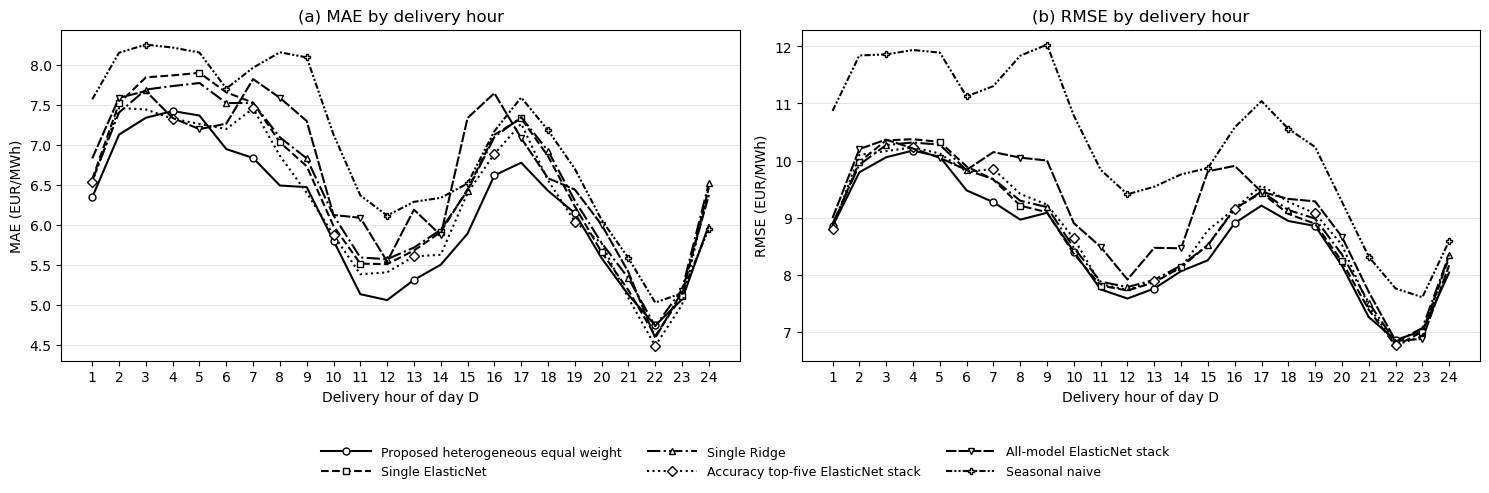

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

# Distinct styles for the six models, suitable for black-and-white printing.
styles = [
    {"linestyle": "-",                  "marker": "o"},
    {"linestyle": "--",                 "marker": "s"},
    {"linestyle": "-.",                 "marker": "^"},
    {"linestyle": ":",                  "marker": "D"},
    {"linestyle": (0, (5, 1)),          "marker": "v"},
    {"linestyle": (0, (3, 1, 1, 1, 1, 1)), "marker": "P"},
]

if len(PLOT_METHODS) > len(styles):
    raise ValueError("Add more distinct styles for the additional models.")

for i, label in enumerate(PLOT_METHODS):
    group = horizon_metrics_df[
        horizon_metrics_df["method"] == label
    ].sort_values("horizon")

    for ax, metric in zip(axes, ["MAE", "RMSE"]):
        ax.plot(
            group["horizon"],
            group[metric],
            label=label,
            color="black",
            linewidth=1.5,
            markersize=5,
            markerfacecolor="white",
            markeredgecolor="black",
            markeredgewidth=1,
            markevery=(i % 3, 3),
            **styles[i],
        )

axes[0].set_title("(a) MAE by delivery hour")
axes[1].set_title("(b) RMSE by delivery hour")

for ax, ylabel in zip(axes, ["MAE (EUR/MWh)", "RMSE (EUR/MWh)"]):
    ax.set_xlabel("Delivery hour of day D")
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(1, 25))
    ax.grid(axis="y", color="0.85", linewidth=0.5)
    ax.set_axisbelow(True)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=3,
    frameon=False,
    handlelength=4,
    fontsize=9,
)

fig.tight_layout(rect=(0, 0.15, 1, 1))

fig.savefig(
    OUT_DIR / "horizon_MAE_RMSE_2018.png",
    dpi=300,
    bbox_inches="tight",
)
# Vector format for publication.
fig.savefig(
    OUT_DIR / "horizon_MAE_RMSE_2018.pdf",
    bbox_inches="tight",
)

plt.show()

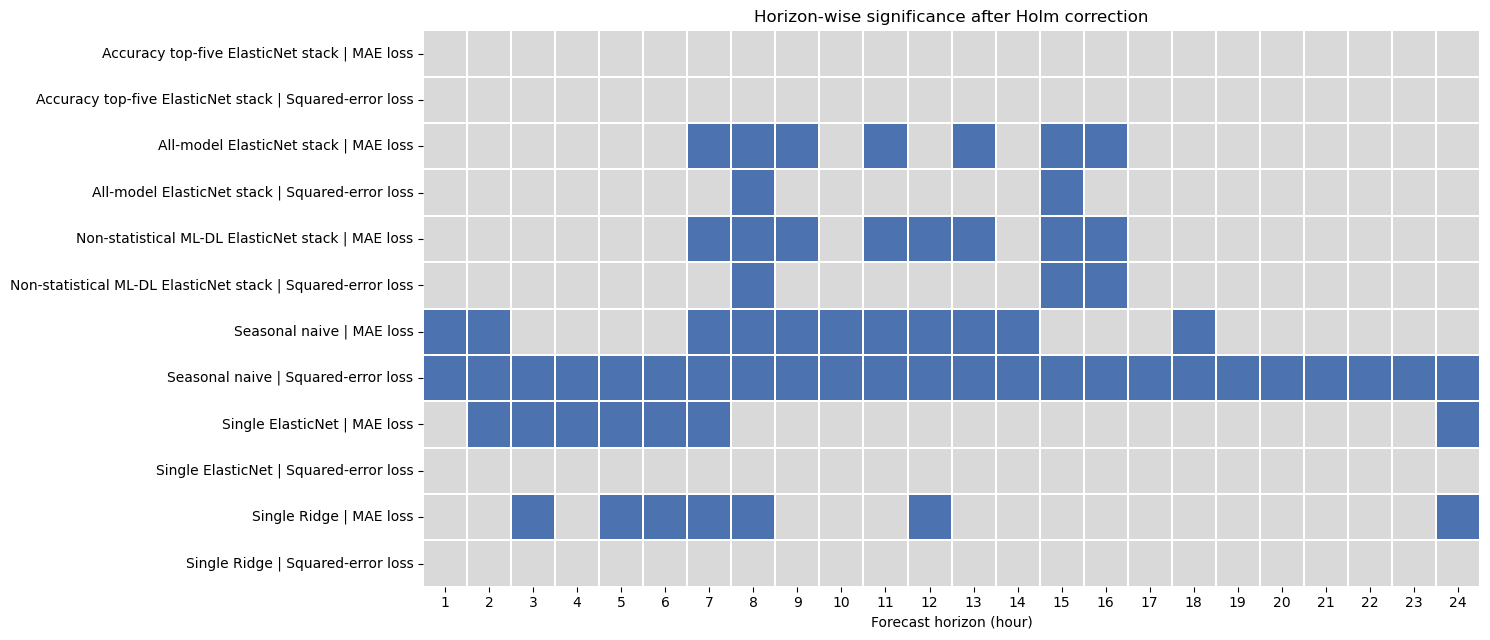

,comparator,loss,significant_horizons,reference_better_horizons,reference_worse_horizons,significant_all_24
0,Accuracy top-five ElasticNet stack,absolute,0,0,0,False
1,Accuracy top-five ElasticNet stack,squared,0,0,0,False
2,All-model ElasticNet stack,absolute,7,7,0,False
3,All-model ElasticNet stack,squared,2,2,0,False
4,Non-statistical ML-DL ElasticNet stack,absolute,8,8,0,False
5,Non-statistical ML-DL ElasticNet stack,squared,3,3,0,False
6,Seasonal naive,absolute,11,11,0,False
7,Seasonal naive,squared,24,24,0,True
8,Single ElasticNet,absolute,7,7,0,False
9,Single ElasticNet,squared,0,0,0,False


In [30]:
# Restrict the significance figure to the principal reviewer-facing comparisons.
SIGNIFICANCE_COMPARATORS = [
    'Single ElasticNet', 'Single Ridge', 'Seasonal naive',
    'Accuracy top-five ElasticNet stack', 'All-model ElasticNet stack',
    'Non-statistical ML-DL ElasticNet stack'
]

sig_plot = horizon_df[horizon_df.comparator.isin(SIGNIFICANCE_COMPARATORS)].copy()
sig_plot['result'] = np.select(
    [sig_plot.significant_0_05 & (sig_plot.mean_loss_advantage > 0),
     sig_plot.significant_0_05 & (sig_plot.mean_loss_advantage < 0)],
    [1, -1], default=0
)
sig_plot['row_label'] = sig_plot['comparator'] + ' | ' + sig_plot['loss'].map(
    {'absolute':'MAE loss','squared':'Squared-error loss'}
)
pivot = sig_plot.pivot(index='row_label', columns='horizon', values='result')

from matplotlib.colors import ListedColormap, BoundaryNorm
cmap = ListedColormap(['#c44e52','#d9d9d9','#4c72b0'])
norm = BoundaryNorm([-1.5,-0.5,0.5,1.5], cmap.N)

plt.figure(figsize=(15, 6.5))
sns.heatmap(pivot, cmap=cmap, norm=norm, cbar=False, linewidths=0.35,
            linecolor='white', square=False)
plt.xlabel('Forecast horizon (hour)')
plt.ylabel('')
plt.title('Horizon-wise significance after Holm correction')
plt.tight_layout()
plt.savefig(OUT_DIR/'horizon_significance_Holm.png', dpi=300,
            bbox_inches='tight')
plt.show()

horizon_summary = (
    sig_plot.groupby(['comparator','loss'])
    .agg(
        significant_horizons=('significant_0_05','sum'),
        reference_better_horizons=('result',lambda s:int((s==1).sum())),
        reference_worse_horizons=('result',lambda s:int((s==-1).sum())),
    )
    .reset_index()
)
horizon_summary['significant_all_24'] = horizon_summary.significant_horizons.eq(24)
horizon_summary.to_csv(OUT_DIR/'horizon_significance_summary.csv', index=False)
display(horizon_summary)


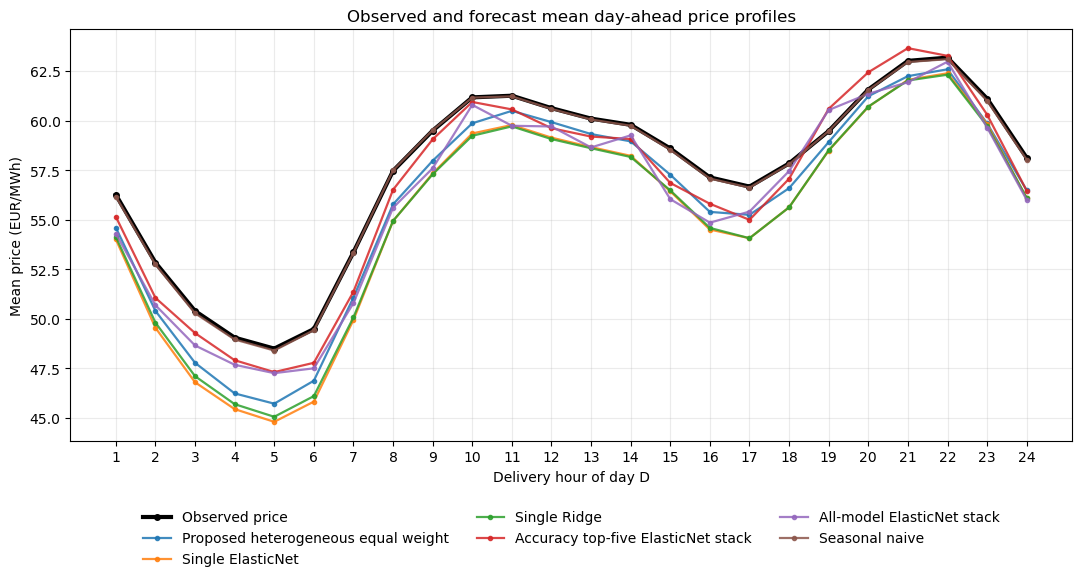

In [32]:
PROFILE_METHODS = {
    "Proposed heterogeneous equal weight":
        "Diversity-guided heterogeneous | Equal weight",
    "Single ElasticNet":
        "Single | ElasticNet",
    "Single Ridge":
        "Single | Ridge",
    "Accuracy top-five ElasticNet stack":
        "Accuracy-only top five | ElasticNet stacking",
    "All-model ElasticNet stack":
        "All 12 models | ElasticNet stacking",
    "Seasonal naive":
        "Single | Naive_day",
}

profile_rows = []

# Observed mean price for each delivery hour
for h in range(24):
    profile_rows.append({
        "method": "Observed price",
        "delivery_hour": h + 1,
        "mean_price": np.mean(y18_all[:, h])
    })

# Mean predicted price for each delivery hour
for label, key in PROFILE_METHODS.items():
    prediction = predictions[key]

    for h in range(24):
        profile_rows.append({
            "method": label,
            "delivery_hour": h + 1,
            "mean_price": np.mean(prediction[:, h])
        })

price_profiles = pd.DataFrame(profile_rows)

plt.figure(figsize=(11, 6))

for method, group in price_profiles.groupby("method", sort=False):
    if method == "Observed price":
        plt.plot(
            group["delivery_hour"],
            group["mean_price"],
            color="black",
            linewidth=3,
            marker="o",
            markersize=4,
            label="Observed price"
        )
    else:
        plt.plot(
            group["delivery_hour"],
            group["mean_price"],
            linewidth=1.6,
            marker="o",
            markersize=3,
            alpha=0.85,
            label=method
        )

plt.xlabel("Delivery hour of day D")
plt.ylabel("Mean price (EUR/MWh)")
plt.title("Observed and forecast mean day-ahead price profiles")
plt.xticks(range(1, 25))
plt.grid(alpha=0.25)
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.14),
    ncol=3,
    frameon=False
)
plt.tight_layout()

plt.savefig(
    OUT_DIR / "observed_forecast_price_profiles_2018.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
price_profiles.to_csv(OUT_DIR / 'observed_forecast_price_profiles_2018.csv', index=False)


## 8. Prediction intervals calibrated only on 2017

The interval forecast is the **fixed heterogeneous equal-weight reference**, not a winner selected from the 2018 table. Its 2017 forecast is the mean of the same five base forecasts used in 2018, so its calibration errors are not in-sample stacking residuals.

For each delivery hour, estimate the 2.5% and 97.5% quantiles of 2017 residuals and add those fixed offsets to 2018 predictions. For daily-average prices, independently calibrate quantiles of the 2017 daily-average residuals; do not average hourly interval endpoints. No 2018 target is used to set any interval bound.

These are nominal 95% empirical residual intervals, not a distribution-free coverage guarantee under temporal dependence or year-to-year shifts. Hourly intervals are marginal per hour, not simultaneous 24-hour path coverage. Daily intervals concern one day's mean price, not monthly means.

Report PICP (coverage), MPIW (mean width), the central interval score and exact CRPS for the empirical residual predictive distribution. CRPS treats each calibration residual as an equally weighted additive forecast error. Scores use only the fixed common 2018 sample. Interval calibration is provided for this fixed reference only; extending it to stacks requires held-out or rolling out-of-sample meta-model residuals.


In [34]:
reference_models = CONFIGURATIONS['Diversity-guided heterogeneous']
_, calibration_y, calibration_X = daily_arrays(g2017, reference_models)
calibration_prediction = calibration_X.mean(axis=2)
calibration_errors = calibration_y - calibration_prediction
reference_prediction = predictions[REFERENCE]
q_lower, q_upper = np.quantile(calibration_errors, [INTERVAL_ALPHA / 2, 1 - INTERVAL_ALPHA / 2], axis=0)
lower_hourly = reference_prediction + q_lower
upper_hourly = reference_prediction + q_upper

calibration_daily_errors = calibration_errors.mean(axis=1)
daily_q_lower, daily_q_upper = np.quantile(calibration_daily_errors, [INTERVAL_ALPHA / 2, 1 - INTERVAL_ALPHA / 2])
daily_prediction = reference_prediction.mean(axis=1)
lower_daily = daily_prediction + daily_q_lower
upper_daily = daily_prediction + daily_q_upper

hourly_intervals = g2018[['time', 'local_day', 'hour', 'y_true']].copy()
hourly_intervals['prediction'] = reference_prediction.ravel()
hourly_intervals['lower_95'] = lower_hourly.ravel()
hourly_intervals['upper_95'] = upper_hourly.ravel()
hourly_intervals.to_csv(OUT_DIR / 'reference_hourly_prediction_intervals_2018.csv', index=False)
daily_intervals = pd.DataFrame({'delivery_day': days18, 'y_true': y18_all.mean(axis=1),
                               'prediction': daily_prediction, 'lower_95': lower_daily, 'upper_95': upper_daily})
daily_intervals.to_csv(OUT_DIR / 'reference_daily_average_prediction_intervals_2018.csv', index=False)
calibration = pd.DataFrame({'horizon': np.arange(1, 25), 'n_calibration_days': len(calibration_errors),
                            'lower_residual_quantile': q_lower, 'upper_residual_quantile': q_upper})
calibration.to_csv(OUT_DIR / 'hourly_interval_calibration_2017.csv', index=False)
pd.DataFrame([{'n_calibration_days': len(calibration_errors), 'lower_residual_quantile': daily_q_lower,
               'upper_residual_quantile': daily_q_upper}]).to_csv(OUT_DIR / 'daily_interval_calibration_2017.csv', index=False)


In [36]:
def empirical_residual_crps(actual, point, residuals):
    actual, point = np.asarray(actual), np.asarray(point)
    residuals = np.sort(np.asarray(residuals, dtype=float))
    m = len(residuals)
    if residuals.ndim != 1 or not m or not np.isfinite(residuals).all():
        raise ValueError('CRPS requires a finite 1D calibration residual sample.')
    # E|X-y| - 0.5 E|X-X'| for the equally weighted empirical distribution.
    first = np.abs((actual - point)[:, None] - residuals[None, :]).mean(axis=1)
    half_pairwise = np.dot(2 * np.arange(1, m + 1) - m - 1, residuals) / m ** 2
    return first - half_pairwise


def interval_scores(actual, lower, upper, crps):
    actual, lower, upper = map(np.asarray, (actual, lower, upper))
    if not np.isfinite([actual, lower, upper]).all() or (upper < lower).any():
        raise ValueError('Invalid interval bounds.')
    score = (upper - lower) + (2 / INTERVAL_ALPHA) * (np.maximum(lower - actual, 0) + np.maximum(actual - upper, 0))
    return {'PICP': float(np.mean((actual >= lower) & (actual <= upper))),
            'MPIW': float(np.mean(upper - lower)), 'interval_score': float(np.mean(score)),
            'CRPS': float(np.mean(crps)), 'n_predictions': actual.size,
            'nominal_coverage': 1 - INTERVAL_ALPHA}

hourly_crps = np.column_stack([empirical_residual_crps(y18_all[:, h], reference_prediction[:, h], calibration_errors[:, h])
                               for h in range(24)])
daily_crps = empirical_residual_crps(y18_all.mean(axis=1), daily_prediction, calibration_daily_errors)
interval_rows = [dict(resolution='hourly_pooled', **interval_scores(y18_all, lower_hourly, upper_hourly, hourly_crps)),
                 dict(resolution='daily_average', **interval_scores(y18_all.mean(axis=1), lower_daily, upper_daily, daily_crps))]
interval_metrics = pd.DataFrame(interval_rows)
interval_metrics.to_csv(OUT_DIR / 'prediction_interval_metrics_2018.csv', index=False)
pd.DataFrame([dict(horizon=h + 1, **interval_scores(y18_all[:, h], lower_hourly[:, h], upper_hourly[:, h], hourly_crps[:, h]))
              for h in range(24)]).to_csv(OUT_DIR / 'hourly_prediction_interval_metrics_2018.csv', index=False)
display(interval_metrics)


,resolution,PICP,MPIW,interval_score,CRPS,n_predictions,nominal_coverage
0,hourly_pooled,0.959257,38.745500,52.978869,4.393470,8664,0.95
1,daily_average,0.958449,33.941241,44.508150,3.666741,361,0.95


## 9. Daily-average interval plots and reproducibility

January and December 2018 are fixed descriptive views of the reference forecast. Missing common-sample days remain gaps. Labels refer to the same reference model and evaluation year throughout.


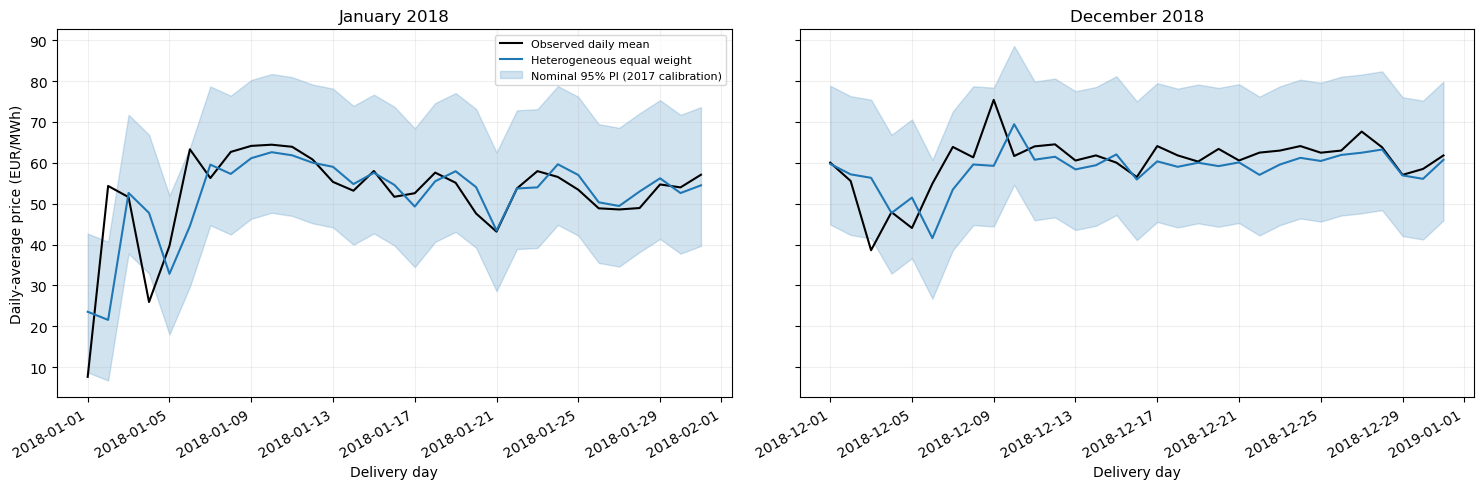

Saved ensemble analysis to: /Users/fatimarodrigues/Documents/Aulas/MINDD/Trabs-Pratico/2025-26/TP2-2025/git-price-forecasting/electricity-price-forecasting-revisão/initial-weather/outputs/ensemble_ablation


In [38]:
plot_daily = daily_intervals.copy()
plot_daily.index = pd.to_datetime(plot_daily.pop('delivery_day'))
plot_daily = plot_daily.reindex(pd.date_range('2018-01-01', '2018-12-31', freq='D'))
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, month in zip(axes, [1, 12]):
    view = plot_daily.loc[plot_daily.index.month == month]
    ax.plot(view.index, view.y_true, label='Observed daily mean', color='black')
    ax.plot(view.index, view.prediction, label='Heterogeneous equal weight', color='#1f77b4')
    ax.fill_between(view.index, view.lower_95, view.upper_95, alpha=.2, color='#1f77b4', label='Nominal 95% PI (2017 calibration)')
    ax.set_title(view.index[0].strftime('%B %Y'))
    ax.set_xlabel('Delivery day')
    ax.grid(alpha=.2)
axes[0].set_ylabel('Daily-average price (EUR/MWh)')
axes[0].legend(fontsize=8)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(OUT_DIR / 'reference_daily_mean_intervals_january_december_2018.png', dpi=200, bbox_inches='tight')
plt.show()

run_manifest = {
    'versions': {'python': platform.python_version(), 'numpy': np.__version__, 'pandas': pd.__version__,
                 'scipy': scipy.__version__, 'sklearn': sklearn.__version__},
    'timezone': TIMEZONE, 'seed': SEED, 'configurations': CONFIGURATIONS,
    'meta_parameters': {'ridge_alpha': RIDGE_META_ALPHA, 'elasticnet_alpha': ENET_META_ALPHA,
                        'elasticnet_l1_ratio': ENET_META_L1_RATIO},
    'reference': REFERENCE, 'comparators': COMPARATORS,
    'hac_calendar_lags': HAC_LAG, 'bootstrap_calendar_block_days': BOOTSTRAP_BLOCK_DAYS,
    'bootstrap_replications': N_BOOTSTRAP, 'interval_alpha': INTERVAL_ALPHA,
    'interval_calibration_year': 2017, 'evaluation_year': 2018,
    'common_days': {'2017': len(days17), '2018': len(days18)},
    'mase_scale_2018': MASE_SCALE_2018,
    'input_sha256': {str(path.relative_to(PROJECT_ROOT)): hashlib.sha256(path.read_bytes()).hexdigest()
                     for path in dict.fromkeys(INPUT_PATHS)},
}
(OUT_DIR / 'run_manifest.json').write_text(json.dumps(run_manifest, indent=2))
print('Saved ensemble analysis to:', OUT_DIR)


## Interpretation

Use the common-sample table for every principal comparison. Keep composition selection separate from aggregation: a useful heterogeneous subset does not establish that stacking improves it. Positive loss advantages favor the fixed reference; Holm-adjusted p-values and the declared test families determine significance claims. A nonsignificant result means insufficient evidence of a difference, not demonstrated equivalence.

Bootstrap performance confidence intervals and prediction intervals answer different questions. Report empirical 2018 coverage alongside the nominal interval level; do not recalibrate to make test coverage appear closer to 95%. Calendar gaps, temporal dependence, possible distribution shift and the reused development year limit generalization beyond this experiment.
